[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/19_nlp_topic_modeling_and_sentiment.ipynb)

# 📓 Notebook 19 (fast track) — NLP: Topic Modeling & Sentiment

> **Module:** NLP (Text Analytics) · **Estimated time:** 65–80 min · **Difficulty:** Intermediate

Text is the most common data in business — reviews, support tickets, survey verbatims, chat logs — and the least structured. This notebook condenses the canonical [`09_nlp/`](../09_nlp/) module (NB 35 **BERTopic**, NB 37 **sentiment analysis**) into one fast-track pass around two questions: **what** are people talking about, and **how** do they feel about it?

> 🏎️ **You're on the fast track.** The canonical module reaches for the libraries practitioners actually use — **BERTopic**, **sentence-transformers**, **VADER**, Hugging Face **transformers**. Here we run entirely on **pure scikit-learn / NumPy stand-ins**, so nothing heavy needs installing and every cell finishes offline in seconds. These stand-ins are the *exact* fallbacks the canonical notebooks drop to when the big library is absent — same shape, simpler engine. Open [`09_nlp/`](../09_nlp/) when you want the real thing.

> 🧭 **Mental model.** Turn unstructured text into structure you can *act on*. Two axes carry the whole field: **what** they talk about → *topics* (group documents by shared words), and **how they feel** → *sentiment* (score the emotional polarity). Start simple — a plain **bag-of-words** gets you surprisingly far before you ever need a neural network.

**Prerequisites.** Fast-track [Notebook 8](08_sklearn_basics.ipynb) (scikit-learn `fit`/`predict`, pipelines) is the one that matters here; [Notebook 11](11_embeddings_and_rag.ipynb) (embeddings) helps you picture what the "real" semantic versions do under the hood.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Turn a list of raw documents into numeric features with **TF-IDF**, and explain what the weights mean.
2. Discover themes in an *unlabeled* corpus by clustering TF-IDF vectors with **KMeans**, and read each cluster's top terms as its "topic".
3. Map that offline stand-in onto the real **BERTopic** pipeline — *embed → reduce → cluster → describe*.
4. Climb the **sentiment ladder**: a hand-built **lexicon** scorer, then a trained **TF-IDF + LogisticRegression** classifier.
5. Evaluate a text classifier and **inspect `.coef_`** to see exactly which words drive its predictions.
6. Name the failure modes that bite NLP models in production — **arbitrary topic counts, domain shift, and sarcasm**.

## 1. Setup — a tiny, all-offline toolkit

Everything below is `numpy`, `pandas`, `matplotlib`, and `scikit-learn`. No `bertopic`, no `transformers`, no `vaderSentiment` — nothing to download. One fixed `RANDOM_STATE` keeps every run identical.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# One projector-friendly palette for the whole notebook
BLUE, RED, GREEN, ORANGE, PURPLE = "#4C72B0", "#C44E52", "#55A868", "#DD8452", "#8172B3"
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Pure-sklearn NLP toolkit ready ✅  (no bertopic / transformers / vader needed)")

Pure-sklearn NLP toolkit ready ✅  (no bertopic / transformers / vader needed)


## 2. From text to numbers — TF-IDF

A model can't read; it can only do arithmetic. So step zero of *every* classical NLP task is the same: turn each document into a **vector of numbers**. The workhorse is **TF-IDF** — a weighted bag-of-words:

- **TF** (term frequency) — how often a word appears in *this* document.
- **IDF** (inverse document frequency) — down-weights words that appear in *every* document ("the", "and", "product"), because words that are everywhere tell you nothing about what a document is *about*.

Multiply them and each document becomes a sparse vector: mostly zeros, with a few high weights on the words that make it distinctive. That single representation feeds both halves of this notebook.

In [2]:
mini_corpus = [
    "the cloud server auto-scaled during the traffic spike",
    "the patient waited hours in the hospital emergency room",
    "the striker scored the winning goal in the final minute",
]

tiny_vec = TfidfVectorizer(stop_words="english")
tiny_X = tiny_vec.fit_transform(mini_corpus)          # sparse (docs x vocabulary)

print("vocabulary size      :", len(tiny_vec.get_feature_names_out()))
print("matrix shape (docs x terms):", tiny_X.shape)

# Show the weights as a small table (0 = word absent from that document)
tiny_df = pd.DataFrame(
    tiny_X.toarray().round(2),
    columns=tiny_vec.get_feature_names_out(),
    index=["cloud doc", "health doc", "sports doc"],
)
tiny_df

vocabulary size      : 18
matrix shape (docs x terms): (3, 18)


,auto,cloud,emergency,final,goal,hospital,hours,minute,patient,room,scaled,scored,server,spike,striker,traffic,waited,winning
cloud doc,0.41,0.41,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.41,0.00,0.41,0.41,0.00,0.41,0.00,0.00
health doc,0.00,0.00,0.41,0.00,0.00,0.41,0.41,0.00,0.41,0.41,0.00,0.00,0.00,0.00,0.00,0.00,0.41,0.00
sports doc,0.00,0.00,0.00,0.41,0.41,0.00,0.00,0.41,0.00,0.00,0.00,0.41,0.00,0.00,0.41,0.00,0.00,0.41


> 🔬 **Read the table.** Every column is a word from the combined vocabulary; every row is a document turned into numbers. The weights are non-zero only for words the document actually contains, and the *distinctive* words (`cloud`, `hospital`, `striker`) carry the weight while shared filler was dropped by `stop_words="english"`. Three sentences → three points in a high-dimensional space. Documents that share vocabulary sit close together — which is exactly what lets us **cluster** them (Part A) and **classify** them (Part B).

# 🗂️ Part A — Topic modeling: *what* are they talking about?

You have 5,000 support tickets or a year of reviews and nobody will read them all. **Topic modeling** builds the map: which themes exist, how big each is, and roughly what each is about — with *no labels*, learned straight from the text.

The state-of-the-art tool (canonical **NB 35**) is **BERTopic**, a four-stage pipeline:

| BERTopic stage | What it does | Our offline stand-in |
|---|---|---|
| **Embed** | sentence-transformer → semantic vectors | **TF-IDF** vectors (§2) — a real vector space, just not semantic |
| **Reduce** | UMAP shrinks the dimensions | *skipped* — TF-IDF already clusters fine at this scale |
| **Cluster** | HDBSCAN finds dense groups | **KMeans** — but *we* must pick the number of topics |
| **Describe** | c-TF-IDF names each topic | top terms of each **cluster centroid** |

Same shape, humbler engine. Let's build it.

## 3. The corpus — hidden themes to recover

A small corpus of 28 short documents spanning **four deliberately obvious themes** — cloud computing, healthcare, sports, cooking. We keep the theme labels *only to grade ourselves*; the model never sees them.

In [3]:
topic_docs = [
    # ☁️ cloud computing
    "Our team migrated the whole backend to the cloud last quarter.",
    "The cloud server auto-scales whenever traffic spikes.",
    "We deploy our containers to cloud servers with Kubernetes.",
    "Serverless cloud functions scale down to zero when idle.",
    "Cloud storage gives us cheap and reliable nightly backups.",
    "The monthly cloud server bill jumped after a config change.",
    "Moving compute onto nearby cloud servers cut our latency.",
    # 🏥 healthcare
    "The hospital tracks every patient with electronic health records.",
    "Early diagnosis helps patients recover from chronic disease.",
    "Nurses check each patient blood pressure every hour at the hospital.",
    "A new drug eased patient symptoms during the clinical trial.",
    "Telemedicine lets a patient consult a hospital doctor from home.",
    "The hospital emergency room had long patient wait times.",
    "Doctors review patient scans before every hospital discharge.",
    # ⚽ sports
    "The team scored three goals to win the match.",
    "Our team defense collapsed late in the game.",
    "The team trains twice a day before every match.",
    "Fans packed the stadium for the championship game.",
    "The coach changed the team tactics at half time in the match.",
    "The team lost the away match after a red card.",
    "A last minute goal won the team the title game.",
    # 🍳 cooking
    "This recipe roasts the garlic before the tomato sauce.",
    "Let the dough rest so the recipe bakes up light.",
    "A pinch of salt balances the sweetness in this recipe.",
    "Simmer the sauce for hours to deepen the recipe flavour.",
    "Fresh basil and olive oil finish this pasta recipe.",
    "Sear the steak on high heat then rest before slicing.",
    "Toast the spices first to bring out the recipe aroma.",
]
themes = ["cloud"] * 7 + ["healthcare"] * 7 + ["sports"] * 7 + ["cooking"] * 7

print(f"{len(topic_docs)} documents across {len(set(themes))} hidden themes "
      f"(labels kept only to check our work).")

28 documents across 4 hidden themes (labels kept only to check our work).


## 4. Cluster with KMeans, then describe each topic

Three moves: **(1)** vectorize the documents with TF-IDF, **(2)** run **KMeans** to group them into `K` clusters, **(3)** read the top-weighted terms of each cluster's centroid as that topic's "label". That trio *is* the offline stand-in for BERTopic.

In [4]:
K = 4  # we must choose K ourselves — KMeans can't discover it (⚠️ see the note below)

topic_vec = TfidfVectorizer(stop_words="english")
topic_X = topic_vec.fit_transform(topic_docs)          # (28 docs x vocabulary)
terms = np.array(topic_vec.get_feature_names_out())

km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
clusters = km.fit_predict(topic_X)                     # a cluster id per document

print("cluster id per document:")
print(clusters)

cluster id per document:
[2 2 2 2 2 2 2 3 3 3 3 3 3 3 1 1 1 1 1 1 1 0 0 0 0 0 3 0]


In [5]:
def top_terms(cluster_id, n=6):
    # top-n terms of a cluster centroid = its c-TF-IDF-style "topic" label
    centroid = km.cluster_centers_[cluster_id]         # average TF-IDF profile
    top = np.argsort(centroid)[::-1][:n]               # highest-weighted terms
    return terms[top].tolist()

print("Discovered topics (top terms of each cluster centroid):\n")
for c in range(K):
    n_docs = int((clusters == c).sum())
    print(f"  Topic {c} (n={n_docs:>2}):  {', '.join(top_terms(c))}")

Discovered topics (top terms of each cluster centroid):

  Topic 0 (n= 6):  recipe, sauce, roasts, garlic, tomato, bring
  Topic 1 (n= 7):  team, match, game, goals, trains, scored
  Topic 2 (n= 7):  cloud, servers, server, migrated, quarter, backend
  Topic 3 (n= 8):  patient, hospital, discharge, scans, review, health


Those four term-lists are unmistakable: *cloud/servers*, *patient/hospital*, *team/match*, *recipe/sauce*. KMeans recovered the themes from raw text with **no labels** — that is topic modeling in miniature. Now let's grade it against the themes we secretly kept.

In [6]:
# Cross-tabulate the TRUE theme against the DISCOVERED cluster.
# A clean diagonal (each theme concentrated in one cluster) = good recovery.
recovery = pd.crosstab(pd.Series(themes, name="true theme"),
                       pd.Series(clusters, name="cluster"))
print(recovery)

# Each document with its assigned topic label
doc_topics = pd.DataFrame({
    "document": [d[:52] + "…" for d in topic_docs],
    "cluster": clusters,
    "topic label": [" / ".join(top_terms(c, 3)) for c in clusters],
})
doc_topics.head(8)

cluster     0  1  2  3
true theme            
cloud       0  0  7  0
cooking     6  0  0  1
healthcare  0  0  0  7
sports      0  7  0  0


,document,cluster,topic label
0,Our team migrated the whole backend to the clo...,2,cloud / servers / server
1,The cloud server auto-scales whenever traffic ...,2,cloud / servers / server
2,We deploy our containers to cloud servers with...,2,cloud / servers / server
3,Serverless cloud functions scale down to zero ...,2,cloud / servers / server
4,Cloud storage gives us cheap and reliable nigh...,2,cloud / servers / server
5,The monthly cloud server bill jumped after a c...,2,cloud / servers / server
6,Moving compute onto nearby cloud servers cut o...,2,cloud / servers / server
7,The hospital tracks every patient with electro...,3,patient / hospital / discharge


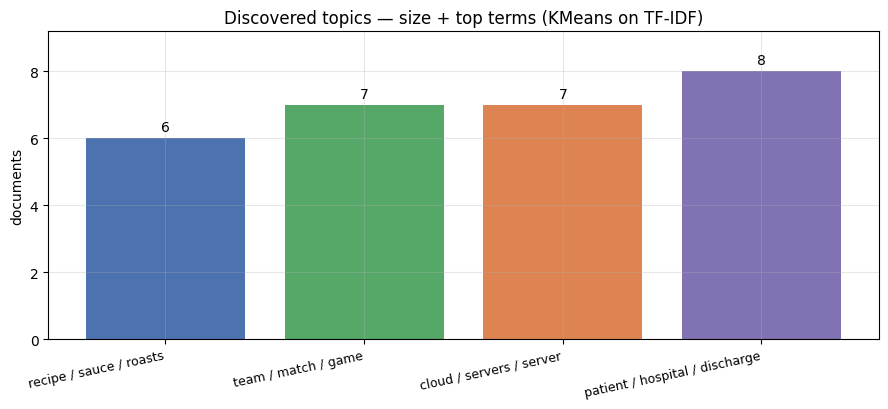

In [7]:
# The same recovery as a picture: cluster sizes labelled with their top terms
sizes = [int((clusters == c).sum()) for c in range(K)]
labels = [" / ".join(top_terms(c, 3)) for c in range(K)]
palette = [BLUE, GREEN, ORANGE, PURPLE]

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(range(K), sizes, color=palette[:K])
ax.bar_label(bars, padding=3)
ax.set_xticks(range(K))
ax.set_xticklabels(labels, rotation=12, ha="right", fontsize=9)
ax.set(ylabel="documents", title="Discovered topics — size + top terms (KMeans on TF-IDF)")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

> 🧠 **Where this maps to BERTopic.** Our `top_terms(c)` is a stand-in for BERTopic's **c-TF-IDF** topic representation; `km.fit_predict` stands in for **HDBSCAN**; and the TF-IDF matrix stands in for the **sentence-transformer embeddings + UMAP**. Swap those three engines back in and you *have* BERTopic — the workflow you just ran is identical.

> ⚠️ **Two honest caveats — read the topics, don't trust the count.**
> 1. **We chose `K=4`.** KMeans can't discover the number of topics; give it `K=3` and it *will* merge two themes, `K=6` and it *will* split one. Real BERTopic/HDBSCAN infers the count from density and keeps an **outlier topic `-1`** for documents that fit nowhere — KMeans has no such escape hatch, so every document is forced into a cluster (watch the one cooking doc that leaked).
> 2. **TF-IDF is bag-of-words, not meaning.** It clusters on *shared words*, so "car" and "automobile" look unrelated. That's the semantic gap embeddings close — and the reason the stand-in is a teaching tool, not a production one. (A note on scaling: TF-IDF vectors are L2-normalised by default, so KMeans' Euclidean distance already behaves like cosine similarity here. On *raw counts* you would have to normalise first, or long documents would dominate.)

---

### ✋ Quick exercise (~2 min) — Read a cluster's topic

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Pick any cluster id in `range(K)` and pull its **top 5 terms** — the words that define that topic. Use the `top_terms(cluster_id, n)` helper we just wrote.

```python
# top_terms(cluster_id, n) returns a list of the n highest-weighted terms.
```

In [8]:
# ✍️ Your turn 👇
chosen = 0            # pick any cluster id: 0, 1, 2, or 3
top5 = ...            # the 5 highest-weighted terms for cluster `chosen`

<details>
<summary>✅ <b>Solution</b></summary>

```python
chosen = 0
top5 = top_terms(chosen, 5)
print(f"Topic {chosen} — top 5 terms: {top5}")
```

`top_terms` sorts that cluster's centroid (its average TF-IDF profile) and returns the highest-weighted words. Those words *are* the topic label — the same thing BERTopic's `get_topic(id)` gives you, just computed with a centroid instead of c-TF-IDF.
</details>

# 🌡️ Part B — Sentiment: *how* do they feel?

Topics told you *what* the text is about. **Sentiment** tells you the *feeling* — positive, negative, or neutral — the signal you aggregate to answer "did satisfaction drop after the price change?" or "route this angry ticket to a human now."

The canonical **NB 37** frames it as a **ladder** — climb only as high as the problem forces you:

| Rung | Method | Training? | Strength | Weakness |
|---|---|---|---|---|
| **1** | **Lexicon** (word → valence + rules) | none | instant, transparent | brittle, blind to unknown words |
| **2** | **TF-IDF + LogisticRegression** | labeled data | the in-domain **workhorse** | domain-bound |
| **3** | **Transformer** (e.g. Hugging Face) | pre-trained | context-aware, strongest | heaviest, slowest |

We'll build rungs 1 and 2 for real, and describe rung 3. Six running examples — including deliberate **negation** and **mixed-opinion** traps — get scored on every rung so you can watch each method pass or fail on identical text.

In [9]:
snippets = [
    "I love it, best purchase this year, works great and fast",   # clearly positive
    "Terrible and slow, the worst, I am so disappointed",         # clearly negative
    "It is okay, nothing special",                                # neutral / uncertain
    "This is not great, I would avoid it",                        # negation trap
    "Great quality but it broke and stopped working",            # dictionary blind spot
]
for s in snippets:
    print("•", s)

• I love it, best purchase this year, works great and fast
• Terrible and slow, the worst, I am so disappointed
• It is okay, nothing special
• This is not great, I would avoid it
• Great quality but it broke and stopped working


## 5. Rung 1 — a hand-built lexicon

The simplest sentiment method needs no training at all: keep a dictionary of **word → valence** (how positive/negative each word is), add a couple of rules, and sum the scores. This is a miniature of what **VADER** does. Two rules earn their keep immediately:

- **Negation** — the word after *not / no / never* gets its sign flipped ("not **good**" → negative).
- **Thresholding** — small totals near zero are called *neutral* rather than forced into positive/negative.

In [10]:
# A tiny sentiment lexicon: word -> valence. Positive words score up, negative down.
POS = {"love": 2.5, "loved": 2.5, "great": 2.0, "good": 1.5, "gorgeous": 2.0,
       "best": 2.5, "excellent": 2.5, "amazing": 2.5, "fine": 0.8, "happy": 1.8,
       "fast": 1.0, "reliable": 1.2, "recommend": 1.5}
NEG = {"terrible": -2.5, "bad": -1.5, "broken": -2.0, "overheats": -1.5,
       "avoid": -1.8, "outrageous": -1.5, "slow": -1.2, "hate": -2.5,
       "worst": -2.5, "awful": -2.5, "disappointed": -1.8, "useless": -2.0}
NEGATIONS = {"not", "no", "never", "n't"}


def lexicon_score(text):
    # sum word valences left-to-right, flipping the word right after a negation
    score, negate = 0.0, False
    for tok in re.findall(r"[a-z']+", text.lower()):
        if tok in NEGATIONS:
            negate = True
            continue
        val = POS.get(tok, 0.0) + NEG.get(tok, 0.0)
        if val != 0.0:
            score += -val if negate else val   # flip sign if a negation preceded it
            negate = False
    return score


def lexicon_label(text, thresh=1.0):
    s = lexicon_score(text)
    return "positive" if s > thresh else "negative" if s < -thresh else "neutral"


print(f"{'score':>6}  {'label':<9}  text")
print("-" * 64)
for s in snippets:
    print(f"{lexicon_score(s):>6.1f}  {lexicon_label(s):<9}  {s[:44]}")

 score  label      text
----------------------------------------------------------------
   8.0  positive   I love it, best purchase this year, works gr
  -8.0  negative   Terrible and slow, the worst, I am so disapp
   0.0  neutral    It is okay, nothing special
  -3.8  negative   This is not great, I would avoid it
   2.0  positive   Great quality but it broke and stopped worki


> 🔬 **Watch the traps.** The clear cases land where you'd expect; two others are the whole lesson. *"This is **not** great, I would avoid it"* comes out **negative** — the negation rule flipped `great`, and `avoid` piled on: the rules earning their keep. But *"Great quality but it **broke** and stopped working"* is scored **positive** — the lexicon has `great` in its dictionary but not `broke`, so it simply never sees the problem. That blind spot — *any word missing from the dictionary is invisible* — is the lexicon's fatal weakness, and exactly what a trained model fixes next.

---

### ✋ Quick exercise (~2 min) — Trip up the lexicon

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Score the double-negative review below with `lexicon_score`, and label it with `lexicon_label`. Does the naive one-word negation rule get *"Not bad at all"* right?

```python
review = "Not bad at all, honestly the best gadget I have owned."
```

In [11]:
# ✍️ Your turn 👇
review = "Not bad at all, honestly the best gadget I have owned."
score = ...     # lexicon_score(review)
label = ...     # lexicon_label(review)

<details>
<summary>✅ <b>Solution</b></summary>

```python
review = "Not bad at all, honestly the best gadget I have owned."
score = lexicon_score(review)
label = lexicon_label(review)
print(f"score = {score:+.1f}  ->  {label}")
```

It lands **positive**: the negation rule flips `bad` (−1.5) to +1.5, and `best` (+2.5) pushes it further up. The rule got this one right — but only by luck. It flips just the *immediately following* valence word, so *"not at all bad"* (negator and word separated) would slip through. That fragility is exactly why the trained model in §6 tends to win in-domain.
</details>

## 6. Rung 2 — TF-IDF + LogisticRegression ⭐ the workhorse

Give the model *labeled examples* and let it learn the vocabulary itself. This rung is plain scikit-learn — the same `Pipeline` you built in NB 8 — and it is shockingly hard to beat *in-domain*. Here are ~48 short product reviews, labeled `1` (positive) / `0` (negative). They deliberately **reuse a core vocabulary** (love / great / excellent vs terrible / broke / slow) so held-out reviews share words with the training set — that overlap is what lets a bag-of-words model generalise. The last rows of each class are "hard" cases that mix in the other side's words.

In [12]:
reviews = [
    ("Absolutely love this product, it works perfectly and looks great", 1),
    ("Best purchase this year, fast delivery and excellent quality", 1),
    ("Great value for money, works perfectly and easy to use", 1),
    ("Excellent build quality and the battery life is great", 1),
    ("Super happy with it, customer support was fast and friendly", 1),
    ("Easy to set up and it just works, highly recommend", 1),
    ("Fantastic quality and great value, would buy again", 1),
    ("Love the sleek design, fast and incredibly easy to use", 1),
    ("Works perfectly, great quality and arrived early, recommend it", 1),
    ("Reliable and well made, excellent value and easy to use", 1),
    ("My favourite gadget, fast reliable and flawless so far", 1),
    ("Great app, easy to use and works perfectly with no bugs", 1),
    ("Amazing quality and the battery lasts forever, love it", 1),
    ("Highly recommend, excellent product and fast friendly support", 1),
    ("Perfect for the price, works great and easy to set up", 1),
    ("Really happy with the quality, fast and reliable, love it", 1),
    ("Great product, excellent value and works perfectly", 1),
    ("Fast, reliable and easy to use, best purchase I have made", 1),
    ("Love it, great design and excellent build quality", 1),
    ("Works great, easy to use and fantastic value for money", 1),
    ("Excellent customer support, fast friendly and very helpful", 1),
    ("Great quality product, reliable and easy to recommend", 1),
    ("Was worried it would be slow but it works perfectly, love it", 1),   # hard
    ("Not the cheapest but excellent quality and fast, worth it", 1),      # hard
    ("Terrible quality, it broke after two days, complete waste of money", 0),
    ("Worst purchase ever, slow and constantly crashes", 0),
    ("Awful product, broke immediately and customer support was useless", 0),
    ("Cheaply made and stopped working, very disappointed", 0),
    ("Do not buy this, it is slow and the quality is terrible", 0),
    ("Broke on day one, poor quality and a complete waste of money", 0),
    ("Disappointed with the quality, slow and crashes constantly", 0),
    ("Terrible customer support, the product is defective and slow", 0),
    ("Worst quality, it broke quickly and was a waste of money", 0),
    ("Poor build quality, the screen cracked and it stopped working", 0),
    ("Awful experience, arrived damaged and the quality is terrible", 0),
    ("Slow and buggy, crashes constantly, very disappointed", 0),
    ("Hate it, defective on arrival and customer support was useless", 0),
    ("Complete waste of money, broke fast and poor quality", 0),
    ("Terrible value, slow and stopped working after a week", 0),
    ("Defective product, broke immediately, requesting a refund", 0),
    ("Poor quality and slow, very disappointed, would not recommend", 0),
    ("Worst product ever, crashes constantly and feels cheaply made", 0),
    ("Awful quality, broke quickly and the support was terrible", 0),
    ("Slow, buggy and unreliable, a complete waste of money", 0),
    ("Disappointed, poor quality and it stopped working fast", 0),
    ("Terrible and defective, broke on day one, waste of money", 0),
    ("Looks great but broke after two days, very disappointed", 0),   # hard
    ("Fast delivery but the product is defective and useless", 0),    # hard
]
review_texts = [t for t, _ in reviews]
review_labels = np.array([y for _, y in reviews])
print(f"{len(reviews)} reviews  |  positives: {review_labels.sum()}  "
      f"negatives: {(review_labels == 0).sum()}")

48 reviews  |  positives: 24  negatives: 24


In [13]:
X_tr, X_te, y_tr, y_te = train_test_split(
    review_texts, review_labels, test_size=0.30,
    random_state=RANDOM_STATE, stratify=review_labels,
)

sentiment_clf = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), stop_words="english")),
    ("lr",    LogisticRegression(max_iter=1000)),
])
sentiment_clf.fit(X_tr, y_tr)

pred = sentiment_clf.predict(X_te)
print(f"Test accuracy: {accuracy_score(y_te, pred):.0%}  (on {len(y_te)} held-out reviews)\n")
print(classification_report(y_te, pred, target_names=["negative", "positive"],
                            zero_division=0))

# A single small split is noisy; 5-fold CV on all rows is a steadier read.
cv = cross_val_score(sentiment_clf, review_texts, review_labels, cv=5)
print(f"5-fold CV accuracy: {cv.mean():.0%} +/- {cv.std():.0%}")

Test accuracy: 100%  (on 15 held-out reviews)

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         8
    positive       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

5-fold CV accuracy: 100% +/- 0%


### Inspecting `.coef_` — *which words* drive the model

This is the superpower of the linear model: `LogisticRegression` learns **one weight per TF-IDF feature**. A large **positive** weight means "this token pushes toward *positive*"; a large **negative** weight pushes toward *negative*. Mapping weights back to the vocabulary turns the model into a human-readable explanation — invaluable for debugging ("*why* did it flag this ticket?") and for earning stakeholder trust.

In [14]:
s_vec = sentiment_clf.named_steps["tfidf"]
s_lr = sentiment_clf.named_steps["lr"]
vocab = np.array(s_vec.get_feature_names_out())
coefs = s_lr.coef_[0]                     # one weight per token (positive class)
order = np.argsort(coefs)                 # ascending: most negative first

print("Most POSITIVE tokens:", vocab[order[-8:][::-1]].tolist())
print("Most NEGATIVE tokens:", vocab[order[:8]].tolist())

Most POSITIVE tokens: ['works', 'excellent', 'love', 'great', 'easy', 'perfectly', 'works perfectly', 'easy use']
Most NEGATIVE tokens: ['broke', 'disappointed', 'poor', 'poor quality', 'waste money', 'waste', 'useless', 'defective']


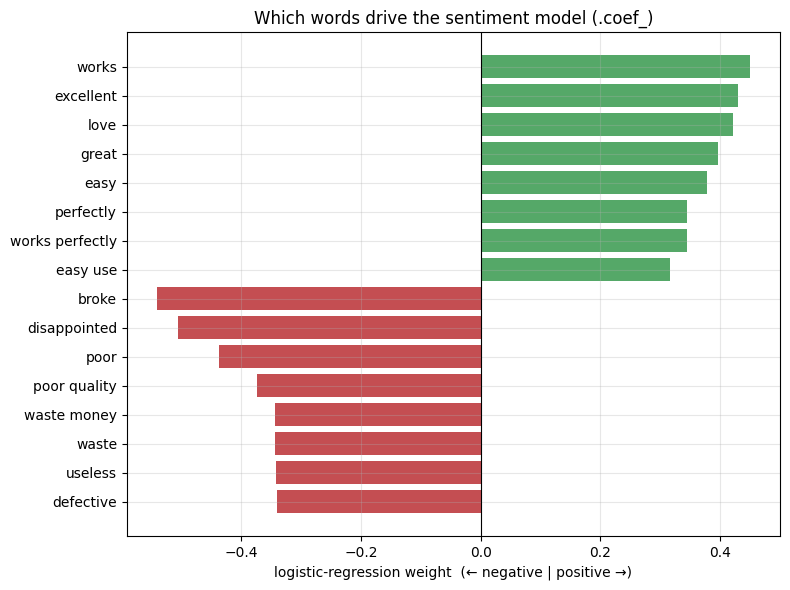

In [15]:
# Visualise the most influential tokens
top_neg = order[:8][::-1]        # eight most negative
top_pos = order[-8:]             # eight most positive
idx = np.concatenate([top_neg, top_pos])
vals = coefs[idx]
colors = [RED if v < 0 else GREEN for v in vals]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(range(len(idx)), vals, color=colors)
ax.set_yticks(range(len(idx)))
ax.set_yticklabels(vocab[idx])
ax.axvline(0, color="black", lw=0.8)
ax.set(xlabel="logistic-regression weight  (← negative | positive →)",
       title="Which words drive the sentiment model (.coef_)")
plt.tight_layout()
plt.show()

The model rediscovered sentiment vocabulary on its own — `love`, `excellent`, `great` on the right, `terrible`, `broke`, `waste` on the left — never told which words were "good". Now put it to work on the six shared snippets and, for each, surface the single token that moved the prediction most.

In [16]:
def top_contributor(text):
    # return the (token, signed push) that most moves THIS text's prediction
    row = s_vec.transform([text]).toarray()[0]   # TF-IDF weights for this text
    contrib = row * coefs                         # per-token push toward positive
    if not np.any(contrib):                       # no word survived into the vocabulary
        return "(no known words)", 0.0
    j = int(np.argmax(np.abs(contrib)))
    return vocab[j], float(contrib[j])


proba = sentiment_clf.predict_proba(snippets)[:, 1]   # P(positive)
print(f"{'P(pos)':>7}  {'label':<9}  {'top driver':<18}  text")
print("-" * 82)
for text, p in zip(snippets, proba):
    word, push = top_contributor(text)
    label = "positive" if p >= 0.5 else "negative"
    print(f"{p:>7.2f}  {label:<9}  {word:<18}  {text[:40]}")

 P(pos)  label      top driver          text
----------------------------------------------------------------------------------
   0.68  positive   works               I love it, best purchase this year, work
   0.36  negative   disappointed        Terrible and slow, the worst, I am so di
   0.52  positive   (no known words)    It is okay, nothing special
   0.61  positive   great               This is not great, I would avoid it
   0.40  negative   broke               Great quality but it broke and stopped w


Line these up against the lexicon in §5 and the two methods' blind spots are mirror images. The classifier **fixes** the *"broke"* review (row 5): it learned from training that `broke` signals trouble, a word the lexicon never had. But it **fails** the negation (row 4) — `not` is an English stop-word, silently dropped before the model ever sees it, so it latches onto `great` and calls it positive, the very case the lexicon's rule handled. And row 3 (*"it is okay, nothing special"*) contains no word the model was trained on, so it shrugs at **≈0.52** — a coin flip, because this binary classifier has *no neutral class*. Each rung fixes the one below and introduces a new blind spot; that is why you climb only as far as the job demands.

> ⚠️ **The two things that break sentiment models.**
> - **Domain shift.** A model trained on gadget reviews will flounder on restaurant or finance text — "*cold*" is bad for soup, neutral for a phone. Bag-of-words knows only the words it was trained on. **Always validate on *your* text** (you'll prove this in Stretch D).
> - **Sarcasm.** *"Great. Another broken update. Just what I needed."* is scored positive by nearly every non-contextual method. Catching it needs a context-aware **transformer** (rung 3) — and even then it is hard.

---

### ✋ Quick exercise (~2 min) — Classify a review and read its top driver

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Classify the review below with the trained `sentiment_clf` (get `P(positive)`), then use `top_contributor` to find the single word that pushed the prediction hardest.

```python
review = "The build quality is excellent and it works perfectly."
```

In [17]:
# ✍️ Your turn 👇
review = "The build quality is excellent and it works perfectly."
p = ...       # P(positive) from sentiment_clf.predict_proba
word = ...    # the top-driving token (use top_contributor)

<details>
<summary>✅ <b>Solution</b></summary>

```python
review = "The build quality is excellent and it works perfectly."
p = sentiment_clf.predict_proba([review])[0, 1]
word, push = top_contributor(review)
print(f"P(positive) = {p:.2f}  ->  {'positive' if p >= 0.5 else 'negative'}")
print(f"biggest driver: {word!r}  (contribution {push:+.3f})")
```

`predict_proba` returns `[P(neg), P(pos)]` per text; column `1` is the positive probability. `top_contributor` multiplies each token's TF-IDF weight by its learned coefficient, so the largest-magnitude product is the word that moved *this* prediction most — here, `excellent`. That per-example explanation is what makes a linear model trustworthy.
</details>

## 7. Rung 3 — transformers (the canonical next step)

When the lexicon is too blunt and the classifier hits a domain wall, you climb to a **transformer**. A pre-trained model like `distilbert-base-uncased-finetuned-sst-2-english` reads a sentence *in context* — so it can tell that "not bad" is positive and that a sarcastic "great" is not — in about three lines:

```python
# (canonical NB 37 — needs `pip install transformers torch`, not run here)
from transformers import pipeline
clf = pipeline("sentiment-analysis")
clf(["Not bad at all!", "Great. Another broken update."])
# -> [{'label': 'POSITIVE', ...}, {'label': 'NEGATIVE', ...}]
```

The cost: hundreds of MB of weights, a GPU-shaped appetite, and far less transparency than `.coef_`. The **golden rule** holds — climb only as high as the problem forces you. A tuned rung-2 model often *matches* a transformer in-domain at a fraction of the cost. See canonical **NB 37** for the real pipeline, domain-specific models (FinBERT, twitter-roberta), and aspect-based sentiment.

## 🧪 Practice exercises

Five short exercises. Try each before opening its solution.

### Exercise 1 — ⭐ Change the topic count

Re-run the topic clustering with `K=3` and again with `K=6` (reuse `topic_X`). Print the cluster sizes each time. Which themes get merged when `K` is too small, and which get split when it's too large?

In [18]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
for k in (3, 6):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    lab = km_k.fit_predict(topic_X)
    sizes = [int((lab == c).sum()) for c in range(k)]
    print(f"K={k}: cluster sizes = {sizes}")
```

With `K=3` two themes are forced to share a cluster (usually the two smallest/closest); with `K=6` one clean theme splits into sub-topics. There is no "right" `K` from the data alone — which is precisely the weakness BERTopic/HDBSCAN removes by *inferring* the count.
</details>

### Exercise 2 — ⭐⭐ Assign a brand-new document to a topic

Take a new sentence — `"We cut costs by moving our servers to the cloud."` — vectorize it with the *already-fitted* `topic_vec`, predict its cluster with `km`, and print the predicted topic's top terms. (Which theme should it land in?)

In [19]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
new_doc = "We cut costs by moving our servers to the cloud."
vec_new = topic_vec.transform([new_doc])      # transform, NOT fit_transform
topic_id = int(km.predict(vec_new)[0])
print(f"Predicted topic {topic_id}: {top_terms(topic_id)}")
```

Key discipline: call `.transform` (never `.fit_transform`) on new data, so it is mapped into the *same* vocabulary the model was trained on. The sentence lands in the cloud/servers cluster. This is exactly how topics power routing — assign each incoming ticket to a theme, then send it to the right queue.
</details>

### Exercise 3 — ⭐⭐ Most positive/negative *single* words

The `.coef_` ranking in §6 mixed unigrams and bigrams. Print the 5 most positive and 5 most negative tokens that are **single words only** (no space in the token).

In [20]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
unigram = np.array([" " not in t for t in vocab])          # True for single words
uni_idx = np.where(unigram)[0]
uni_sorted = uni_idx[np.argsort(coefs[uni_idx])]           # ascending by weight
print("Top 5 positive words:", vocab[uni_sorted[-5:][::-1]].tolist())
print("Top 5 negative words:", vocab[uni_sorted[:5]].tolist())
```

Filtering to unigrams isolates the individual sentiment-bearing words the model latched onto. Bigrams (`ngram_range=(1, 2)`) still help — they capture short phrases like `waste money` — but the unigrams alone already tell most of the story.
</details>

### Exercise 4 — ⭐⭐ Precision and recall by hand

Build the confusion matrix for the held-out test set (`y_te`, `pred`) and compute the **precision** and **recall** of the positive class straight from its four cells — then check them against `classification_report`.

In [21]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
cm = confusion_matrix(y_te, pred)      # rows = actual, cols = predicted; [neg, pos]
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall    = tp / (tp + fn) if (tp + fn) else 0.0
print("confusion matrix:\n", cm)
print(f"positive precision = {precision:.2f}   recall = {recall:.2f}")
```

**Precision** = of the reviews we *called* positive, how many really were (`tp / (tp + fp)`). **Recall** = of the truly positive reviews, how many we *caught* (`tp / (tp + fn)`). They answer different business questions — "can I trust a positive flag?" vs "am I missing unhappy customers?" — which is why you never report accuracy alone.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The cell below wants to vectorize `topic_docs`, but it **raises an exception**. Run it, read the traceback, and fix it in a new cell. (This is a classic scikit-learn slip.)

In [22]:
# 🐞 Buggy — this raises on purpose. Read the error, then write your fix below.
from sklearn.feature_extraction.text import TfidfVectorizer

buggy_vec = TfidfVectorizer(stop_words="english")
buggy_X = buggy_vec.transform(topic_docs)   # ← trying to transform before fitting
print(buggy_X.shape)

NotFittedError: The TF-IDF vectorizer is not fitted

<details>
<summary>💡 <b>Solution</b></summary>

The vectorizer was never **fitted**, so it has no vocabulary yet — calling `.transform` first raises `NotFittedError`. You must learn the vocabulary before you can apply it:

```python
buggy_vec = TfidfVectorizer(stop_words="english")
buggy_X = buggy_vec.fit_transform(topic_docs)   # fit + transform in one call
print(buggy_X.shape)
```

Use `fit_transform` on the **training** text (learn *and* apply), then plain `.transform` on any **new** text (apply the already-learned vocabulary). Calling `.transform` before any `fit` is the ordering bug — the mirror image of it, calling `.transform` on new data with `fit_transform` by mistake, silently *re-learns* the vocabulary and corrupts your features.
</details>

## 🧠 Stretch exercises

Two harder, open-ended exercises. Each solution ends with the reasoning that makes it worth your time.

### Stretch exercise C — ⭐⭐⭐ Let the data suggest `K` (silhouette score)

We hand-picked `K=4`. Use the **silhouette score** to argue for a `K` from the data instead: for `K` in `2…7`, fit KMeans on `topic_X`, compute `silhouette_score(topic_X, labels)`, and plot score vs `K`. Does the peak agree with the four themes we planted?

In [23]:
# Your code here  👇
from sklearn.metrics import silhouette_score

<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.metrics import silhouette_score

ks = range(2, 8)
scores = []
for k in ks:
    lab = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(topic_X)
    scores.append(silhouette_score(topic_X, lab))

best_k = list(ks)[int(np.argmax(scores))]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), scores, "o-", color=BLUE, lw=2)
ax.axvline(best_k, color=GREEN, ls="--", label=f"best K = {best_k}")
ax.set(xlabel="number of clusters K", ylabel="silhouette score",
       title="Silhouette suggests a K from the data")
ax.legend()
plt.tight_layout(); plt.show()
print(f"Silhouette peaks at K = {best_k}")
```

**Reasoning.** The silhouette score measures how much tighter a point sits with its own cluster than with the next-nearest one, so its peak is a *data-driven* vote for `K` — here it typically lands on or very near 4, corroborating the planted themes. But it is still a heuristic: on messy real corpora the curve is often flat or multi-peaked, and "the best `K`" depends on how coarse a map you want. That ambiguity is the whole reason density-based methods like **HDBSCAN** (inside BERTopic) are attractive — they infer the cluster count *and* dump genuine noise into an outlier topic instead of forcing every document into a group.
</details>

### Stretch exercise D — ⭐⭐⭐ Watch a model fall off a domain cliff

Our `sentiment_clf` scored ~90%+ on held-out *gadget* reviews. Test it on a handful of **out-of-domain** labeled reviews (restaurant / movie) and measure the accuracy drop. Print each prediction so you can see *where* it fails.

In [24]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
out_of_domain = [
    ("The pasta was delicious and the service was warm and quick", 1),
    ("A gripping film with stunning performances, loved every minute", 1),
    ("Cosy little bistro, the dessert was the highlight of our night", 1),
    ("The plot dragged and the acting felt wooden and lifeless", 0),
    ("Cold food, rude waiter, and we waited an hour for the bill", 0),
    ("A boring, forgettable movie, I nearly walked out halfway", 0),
]
ood_texts = [t for t, _ in out_of_domain]
ood_labels = np.array([y for _, y in out_of_domain])

ood_pred = sentiment_clf.predict(ood_texts)
print(f"Out-of-domain accuracy: {accuracy_score(ood_labels, ood_pred):.0%}\n")
for text, true, p in zip(ood_texts, ood_labels, ood_pred):
    mark = "✅" if p == true else "❌"
    print(f"{mark}  pred={p}  true={true}  {text[:46]}")
```

**Reasoning.** Accuracy collapses — often to little better than a coin flip — because a bag-of-words model only knows the words it was *trained* on. Nothing taught it that "delicious", "gripping", or "wooden" carry sentiment, and gadget cues like "battery" or "crashes" never appear, so it guesses. This is **domain shift**, and it is why an offline test score is a promise only about *the domain you tested in*. The practitioner fixes are: label some in-domain data and retrain (cheap, effective), or climb to a **transformer** pre-trained on broad text, which degrades far more gracefully across domains. Either way — validate on *your* text before you trust a number.
</details>

## 🧠 Key takeaways

1. **Text → numbers first.** TF-IDF turns each document into a sparse, weighted bag-of-words vector; almost every classical NLP method starts from that one representation.
2. **Topic modeling = cluster, then describe.** Offline: KMeans on TF-IDF, and each cluster centroid's top terms *are* the topic. BERTopic automates the identical shape with embeddings → UMAP → HDBSCAN → c-TF-IDF (plus an outlier topic `-1`).
3. **Don't trust the topic count — read the topics.** KMeans makes you pick `K`, has no outlier bucket, and clusters on word overlap rather than meaning. Always inspect the top terms and sanity-check against known themes.
4. **Sentiment is a ladder.** Lexicon (no training, transparent, brittle) → TF-IDF + LogisticRegression (the in-domain workhorse) → transformers (context-aware, heaviest). Climb only as high as the problem forces you.
5. **A lexicon is just a valence dictionary + a few rules** (negation, thresholding): instant and explainable, but blind to sarcasm and to words it has never seen.
6. **`LogisticRegression.coef_` makes the model self-explaining** — positive weights push positive, negative push negative — so you can name *which words* drove any prediction, for debugging and for trust.
7. **Bag-of-words models are domain-bound.** Domain shift and sarcasm are the two failure modes to watch; validate on *your* text before quoting a score.

## ✅ Self-assessment

- [ ] Turn a list of documents into a TF-IDF matrix and explain what the weights mean
- [ ] Cluster documents with KMeans and extract each cluster's top terms as a topic
- [ ] Explain why KMeans topic modeling needs `K` up front and has no outlier topic
- [ ] Map the offline stand-in onto BERTopic's *embed → reduce → cluster → describe* pipeline
- [ ] Score text with a hand-built lexicon and explain how the negation rule flips a word
- [ ] Train and evaluate a TF-IDF + LogisticRegression sentiment classifier (accuracy, precision/recall, CV)
- [ ] Read `.coef_` to name the words that drive a prediction
- [ ] Name the three rungs of the sentiment ladder and the failure modes (topic count, domain shift, sarcasm)

## 🚀 Next step

Continue with **Notebook 20 (fast track) — Shipping: Scheduling & Deployment**, where a working notebook becomes something that runs on a schedule and serves its predictions to the outside world.

> 📎 **Want the real libraries?** Everything here ran on pure-sklearn stand-ins. For the full-depth treatment — real **BERTopic** (embed → UMAP → HDBSCAN → c-TF-IDF), the **STREAM** multi-model bake-off, **VADER**, and Hugging Face **transformer** pipelines — open the canonical [`09_nlp/`](../09_nlp/) module (NB 35 BERTopic, NB 36 STREAM, NB 37 sentiment). It runs offline too, then swaps in the real backend the moment you `pip install` the library.